cpu
Using Colab cache for faster access to the 'covid19-xray-dataset-train-test-sets' dataset.
Epoch 1/10 | Loss: 3.4937 | Acc: 47.30%
Epoch 2/10 | Loss: 3.3347 | Acc: 58.11%
Epoch 3/10 | Loss: 2.6131 | Acc: 73.65%
Epoch 4/10 | Loss: 1.4783 | Acc: 88.51%
Epoch 5/10 | Loss: 1.3254 | Acc: 91.89%
Epoch 6/10 | Loss: 1.1065 | Acc: 92.57%
Epoch 7/10 | Loss: 1.0622 | Acc: 92.57%
Epoch 8/10 | Loss: 1.0901 | Acc: 93.24%
Epoch 9/10 | Loss: 0.8803 | Acc: 95.27%
Epoch 10/10 | Loss: 0.7118 | Acc: 95.27%
Test Acc: 97.50%


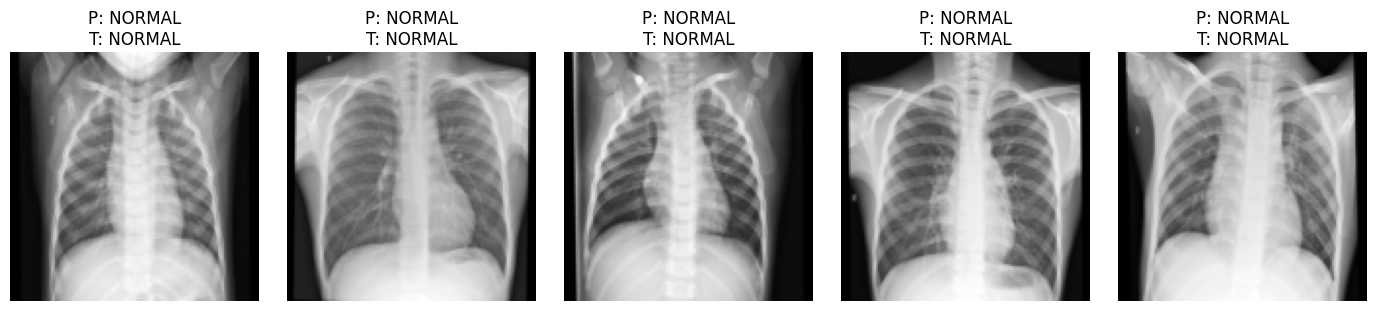

In [2]:
import os
import kagglehub
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

path = kagglehub.dataset_download("khoongweihao/covid19-xray-dataset-train-test-sets")
train_dir = os.path.join(path, "xray_dataset_covid19", "train")
test_dir = os.path.join(path, "xray_dataset_covid19", "test")

transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class PneumoniaCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((4, 4))
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.fc(self.conv(x))

model = PneumoniaCNN(len(train_dataset.classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10
for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f} | Acc: {100*correct/total:.2f}%")

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Acc: {100 * correct / total:.2f}%")

images, labels = next(iter(test_loader))
images_device = images.to(device)

with torch.no_grad():
    outputs = model(images_device)
    _, predicted = torch.max(outputs, 1)

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
for i in range(5):
    axes[i].imshow(images[i].squeeze(), cmap="gray")
    p_class = train_dataset.classes[predicted[i].item()]
    t_class = train_dataset.classes[labels[i].item()]
    axes[i].set_title(f"P: {p_class}\nT: {t_class}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

torch.save(model.state_dict(), "covid_model.pth")